# PINNs from Scratch — Tutorial 4: The 2D Poisson Equation
### Your First PINN in Two Dimensions

*📺 Video on YouTube | 🐍 Python · PyTorch | Beginner–Intermediate*

*Notebook repository: [github.com/rraj-io/pinn-tutorial](https://github.com/rraj-io/pinn-tutorial)*

---

> **This is the tutorial where we leave the number line.**
> Every PINN we have built so far lived on a 1D interval. Today the domain becomes a square, the boundary becomes four edges instead of two points, and the visualizations become heatmaps instead of line plots. The recipe, however, stays *exactly* the same — and seeing that for yourself is the whole point of this tutorial.

---

## Series Roadmap

| # | Tutorial | Status |
|---|----------|--------|
| 0 | Background, Intuition & Setup | ✅ |
| 1 | 1D First-Order ODE — your first working PINN | ✅ |
| 2 | 1D Poisson Equation — second derivatives | ✅ |
| 3 | 1D Burgers Equation — nonlinearity + L-BFGS | ✅ |
| **4** | **2D Poisson Equation — going multidimensional** | **📍 You are here** |
| 5 | 2D Navier–Stokes — the grand finale | 🔜 |


## 1 — What You Will Learn

By the end of this notebook you will have:

- Solved a **partial differential equation in two spatial dimensions** with a PINN
- Computed a **2D Laplacian** ($u_{xx} + u_{yy}$) using chained `torch.autograd.grad` calls
- Sampled collocation points **inside a square domain** and on its **four boundary edges**
- Used the **method of manufactured solutions** to validate your solver — a trick used in professional CFD code verification
- Weighted the boundary loss with a hyperparameter $\lambda_{bc}$ and understood why it matters
- Run the most important experiment in this tutorial: **deleting the boundary loss entirely** — and discovered why a PDE without boundary conditions is not a solvable problem at all

**Prerequisites:** Tutorials 0–3 (autograd basics, the six-step PINN recipe, second derivatives, and the Adam → L-BFGS two-phase training strategy). If you can follow Tutorial 2, you can follow this one — nothing here is conceptually harder, there is just *more of everything*.

⏱️ **Runtime:** the full notebook trains in about **90 seconds on a laptop CPU**. No GPU needed.


## 2 — The Problem We Are Solving

The **2D Poisson equation** on the unit square, with homogeneous Dirichlet boundary conditions:

$$
-\nabla^2 u = -\left( \frac{\partial^2 u}{\partial x^2} + \frac{\partial^2 u}{\partial y^2} \right) = f(x, y), \qquad (x, y) \in \Omega = (0,1) \times (0,1)
$$

$$
u(x, y) = 0 \qquad \text{on } \partial\Omega \text{ (all four edges of the square)}
$$

**Where does this equation show up?** Everywhere. Steady-state heat conduction (u = temperature, f = heat source), electrostatics (u = potential, f = charge density), the pressure equation inside every incompressible CFD solver you will ever run, membrane deflection, groundwater flow. If you learn to solve Poisson, you have learned the workhorse elliptic PDE of engineering.

### The Method of Manufactured Solutions

Instead of picking a source term $f$ and hoping we can find the answer, we do it **backwards** — a standard verification technique in professional solver development:

1. **Choose the solution first.** We pick something smooth that satisfies the boundary conditions by construction:

$$
u(x, y) = \sin(\pi x)\,\sin(\pi y)
$$

Check the boundaries: at $x=0$ or $x=1$, $\sin(\pi x) = 0$. Same for $y$. ✅

2. **Derive the source term** by plugging $u$ into the PDE. Differentiating twice in each direction:

$$
\frac{\partial^2 u}{\partial x^2} = -\pi^2 \sin(\pi x)\sin(\pi y), \qquad
\frac{\partial^2 u}{\partial y^2} = -\pi^2 \sin(\pi x)\sin(\pi y)
$$

$$
\Rightarrow \quad f(x, y) = -\nabla^2 u = 2\pi^2 \sin(\pi x)\,\sin(\pi y)
$$

Now we hand the PINN only $f$ and the boundary conditions, and we check whether it recovers the $u$ we secretly know. **Every error we measure at the end is a true error** — no reference-solver approximation involved, unlike the `solve_bvp` comparison in Tutorial 3.


## 3 — What Actually Changes From 1D to 2D?

Less than you might fear. Here is the honest accounting:

| Ingredient | 1D Poisson (Tutorial 2) | 2D Poisson (this tutorial) |
|---|---|---|
| Network input | 1 neuron ($x$) | **2 neurons** ($x, y$) |
| Network output | 1 neuron ($u$) | 1 neuron ($u$) — unchanged |
| Collocation points | on a line segment | **inside a square** |
| Boundary | 2 points | **4 edges** (sampled with points) |
| Residual | $-u_{xx} - f$ | $-(u_{xx} + u_{yy}) - f$ |
| Autograd calls | 2 (chained) | **4** (two per direction) |
| Validation plot | line plot | **heatmap / contour** |

The training loop, the loss structure, the two-phase Adam → L-BFGS strategy — **all identical**. This is the quiet superpower of PINNs: going from 1D to 2D (or 3D) is mostly a matter of adding input neurons and sampling points in a bigger box. A classical finite-difference code would need a whole new meshing and matrix-assembly layer.

The catch, which we will feel later in the series: the *number of points needed* grows fast with dimension. Park that thought for now.


## 4 — Imports and Setup

Same stack as every tutorial in this series: PyTorch, NumPy, Matplotlib. We fix the random seeds so your numbers match the ones printed in this notebook.


In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import time

torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch version : {torch.__version__}")
print(f"Device          : {device}")

PyTorch version : 2.11.0+cu130
Device          : cpu


**What just happened?** Nothing exciting yet — but note that everything below runs comfortably on `cpu`. The network we are about to build has ~2,200 parameters. Your phone could train it.


## 5 — The Exact Solution and the Source Term

We encode the manufactured solution and its matching source term as plain functions. The exact solution is used **only for validation at the end** — the PINN never sees it during training.


In [2]:
def u_exact(x, y):
    """Manufactured solution: satisfies u = 0 on all four edges by construction."""
    return torch.sin(torch.pi * x) * torch.sin(torch.pi * y)

def source_term(x, y):
    """f = -laplacian(u_exact), derived by hand in Section 2."""
    return 2.0 * torch.pi**2 * torch.sin(torch.pi * x) * torch.sin(torch.pi * y)

Let us look at what we are aiming for before training anything. This is the target field the PINN should reproduce:


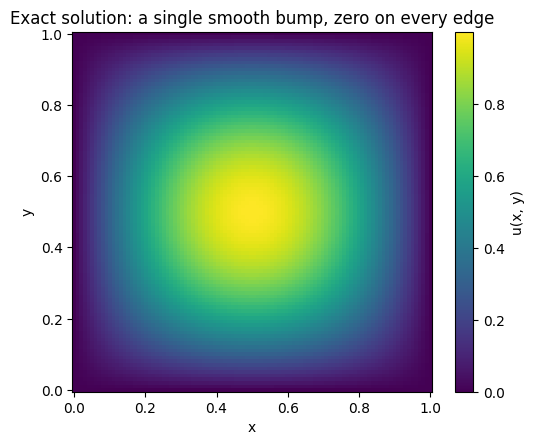

In [3]:
n_plot = 100
xg = torch.linspace(0, 1, n_plot)
yg = torch.linspace(0, 1, n_plot)
X, Y = torch.meshgrid(xg, yg, indexing="ij")

U_target = u_exact(X, Y)

plt.figure(figsize=(5.5, 4.5))
plt.pcolormesh(X, Y, U_target, cmap="viridis", shading="auto")
plt.colorbar(label="u(x, y)")
plt.xlabel("x"); plt.ylabel("y")
plt.title("Exact solution: a single smooth bump, zero on every edge")
plt.gca().set_aspect("equal")
plt.tight_layout()
plt.show()

**What just happened?** A single smooth "bump" peaking at $u(0.5, 0.5) = 1$ and vanishing on all four edges. Physically: think of a square plate heated at the center and clamped to zero temperature along its rim.

One PyTorch detail worth flagging: `torch.meshgrid(..., indexing="ij")`. The `indexing` argument is **mandatory to think about** — `"ij"` gives matrix-style indexing where the first axis is $x$. Mixing up `"ij"` and `"xy"` silently transposes your fields and is a classic source of "my plot looks rotated" bugs.


## 6 — Collocation Points, Now in 2D

In 1D we scattered points along a line. Now we scatter them inside the square. We use **uniform random sampling**: two independent draws from $[0,1]$, one for each coordinate.

The crucial line — same as in every tutorial so far — is `requires_grad_(True)`. Without it, autograd cannot differentiate the network output with respect to the inputs, and the whole PINN idea collapses (Tutorial 0, Section 3, if you need a refresher).


In [4]:
N_interior = 2000

x_int = torch.rand(N_interior, 1)
y_int = torch.rand(N_interior, 1)

x_int.requires_grad_(True)
y_int.requires_grad_(True)

print(x_int.shape, y_int.shape)

torch.Size([2000, 1]) torch.Size([2000, 1])


**Why 2,000 points?** In Tutorial 2 we used a few hundred points on a 1D interval. The square has *area*, not length — to keep a comparable point density we need roughly the square of the 1D count. This is your first taste of the **curse of dimensionality**: at 3D you would want ~100,000 points for the same density, and in high dimensions random/quasi-random sampling is the only game in town. (This scaling problem is exactly why "the collocation point problem" deserves its own discussion later in the series.)

**Why keep `x` and `y` as two separate `(N, 1)` tensors** instead of one `(N, 2)` tensor? Because we need $\partial u / \partial x$ and $\partial u / \partial y$ *separately*. Keeping the coordinates in separate leaf tensors makes each `autograd.grad` call unambiguous. We concatenate them only at the moment they enter the network.


## 7 — Sampling the Boundary: Four Edges

In 1D the boundary was two points — we could just hard-code them. In 2D the boundary of the unit square is four line segments:

- **Bottom:** $y = 0$, $x \in [0, 1]$
- **Top:** $y = 1$, $x \in [0, 1]$
- **Left:** $x = 0$, $y \in [0, 1]$
- **Right:** $x = 1$, $y \in [0, 1]$

We sample 100 random points on each edge and stack them into one boundary batch. The target value is $u = 0$ everywhere on the boundary.


In [5]:
N_per_edge = 100

t = torch.rand(N_per_edge, 1)          # random positions along an edge
zeros = torch.zeros(N_per_edge, 1)
ones  = torch.ones(N_per_edge, 1)

#                 bottom  top   left   right
x_bc = torch.cat([t,      t,    zeros, ones ], dim=0)
y_bc = torch.cat([zeros,  ones, t,     t    ], dim=0)

u_bc = torch.zeros(4 * N_per_edge, 1)   # Dirichlet target: u = 0

print(x_bc.shape, y_bc.shape, u_bc.shape)

torch.Size([400, 1]) torch.Size([400, 1]) torch.Size([400, 1])


⚠️ **A subtle but important simplification in the cell above:** we reused the *same* random tensor `t` for all four edges, so the bottom and top edges share their $x$-positions. For this tutorial it makes no difference. In your own code, drawing fresh samples per edge is slightly cleaner. What *does* matter: **no `requires_grad_` here.** The boundary loss only compares network *outputs* to target *values* — no derivatives of $u$ are needed at the boundary for a Dirichlet condition. Fewer graph nodes, faster training.

Let us visualize the full point cloud — this picture *is* the problem setup:


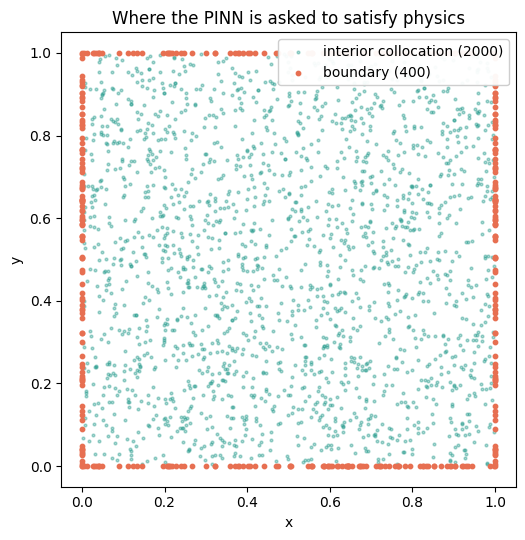

In [6]:
plt.figure(figsize=(5.5, 5.5))
plt.scatter(x_int.detach(), y_int.detach(), s=4, alpha=0.4,
            color="#2A9D8F", label=f"interior collocation ({N_interior})")
plt.scatter(x_bc, y_bc, s=10, color="#E76F51",
            label=f"boundary ({4 * N_per_edge})")
plt.xlabel("x"); plt.ylabel("y")
plt.title("Where the PINN is asked to satisfy physics")
plt.legend(loc="upper right", framealpha=0.95)
plt.gca().set_aspect("equal")
plt.tight_layout()
plt.show()

**What just happened?** Teal points are where we will enforce the **PDE residual**; coral points are where we will enforce the **boundary condition**. Note the `.detach()` on the interior points — they carry gradient tracking now, and Matplotlib wants plain numbers. This picture generalizes to every PINN you will ever build: some points get physics, some points get data/boundary values, and the loss stitches them together.


## 8 — The Network: One More Input Neuron

Here is the *entire* architectural change from Tutorial 2: the first `Linear` layer takes **2 inputs instead of 1**. That's it.

We keep the choices justified in earlier tutorials: `tanh` activations (smooth, infinitely differentiable — Tutorial 0, Section 5) and Xavier initialization (Tutorial 3).


In [7]:
class PINN(nn.Module):
    def __init__(self, n_hidden=32, n_layers=3):
        super().__init__()
        layers = [nn.Linear(2, n_hidden), nn.Tanh()]        # <-- 2 inputs: (x, y)
        for _ in range(n_layers - 1):
            layers += [nn.Linear(n_hidden, n_hidden), nn.Tanh()]
        layers += [nn.Linear(n_hidden, 1)]                  # 1 output: u
        self.net = nn.Sequential(*layers)

        for m in self.net:
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x, y):
        return self.net(torch.cat([x, y], dim=1))   # join coordinates at the door

model = PINN().to(device)
n_params = sum(p.numel() for p in model.parameters())
print(model)
print(f"Trainable parameters: {n_params}")

PINN(
  (net): Sequential(
    (0): Linear(in_features=2, out_features=32, bias=True)
    (1): Tanh()
    (2): Linear(in_features=32, out_features=32, bias=True)
    (3): Tanh()
    (4): Linear(in_features=32, out_features=32, bias=True)
    (5): Tanh()
    (6): Linear(in_features=32, out_features=1, bias=True)
  )
)
Trainable parameters: 2241


**What just happened?** 2,241 parameters — a genuinely tiny network. The `forward` method takes `x` and `y` as separate arguments and concatenates them into an `(N, 2)` batch right before the first layer. This keeps the autograd bookkeeping from Section 6 intact: `x` and `y` remain separate leaf tensors that we can differentiate against individually.


## 9 — The PDE Residual: Building a Laplacian With Autograd

The heart of the tutorial. We need

$$
r(x, y) = -(u_{xx} + u_{yy}) - f(x, y)
$$

evaluated at every interior collocation point. In Tutorial 2 you built $u_{xx}$ by calling `autograd.grad` twice in a row — differentiate, then differentiate the derivative. Now we simply do that **once per direction**: four calls total.


In [8]:
def pde_residual(model, x, y):
    u = model(x, y)

    # First derivatives
    u_x = torch.autograd.grad(u, x, grad_outputs=torch.ones_like(u),
                              create_graph=True)[0]
    u_y = torch.autograd.grad(u, y, grad_outputs=torch.ones_like(u),
                              create_graph=True)[0]

    # Second derivatives (differentiate the derivatives)
    u_xx = torch.autograd.grad(u_x, x, grad_outputs=torch.ones_like(u_x),
                               create_graph=True)[0]
    u_yy = torch.autograd.grad(u_y, y, grad_outputs=torch.ones_like(u_y),
                               create_graph=True)[0]

    f = source_term(x, y)
    return -(u_xx + u_yy) - f

**Three details that separate working code from cryptic error messages:**

1. **`create_graph=True` on every call.** The first derivatives must themselves be differentiable (to get second derivatives), and the second derivatives must be differentiable too (so the *training* backward pass can flow through the residual into the network weights). Forget it once and you get either a `RuntimeError` or — worse — silently frozen training.

2. **The `[0]` at the end of every call.** `torch.autograd.grad()` always returns a *tuple*, even when you differentiate with respect to a single tensor. The `[0]` unpacks it. Omit it and the very next line fails with a confusing `'tuple' object has no attribute ...` error. (Covered in Tutorial 1 — worth repeating forever.)

3. **`u_x` is differentiated w.r.t. `x`, `u_y` w.r.t. `y`.** We never need the mixed derivative $u_{xy}$ for the Laplacian. A common beginner instinct is to compute a full Hessian — unnecessary and expensive.

**Cost check:** each additional spatial dimension adds one first-derivative and one second-derivative call. The graph gets deeper, memory grows, backprop slows. For 2D Poisson this is negligible; for 3D unsteady Navier–Stokes it becomes a real bill. Remember this when you hear people discuss PINN training cost.


## 10 — The Loss Function

Structurally identical to Tutorial 2 — two mean-squared terms:

$$
\mathcal{L} = \underbrace{\frac{1}{N_{int}} \sum_i r(x_i, y_i)^2}_{\text{PDE residual loss}}
\; + \; \lambda_{bc} \underbrace{\frac{1}{N_{bc}} \sum_j \left( \hat{u}(x_j, y_j) - 0 \right)^2}_{\text{boundary loss}}
$$

New here is the explicit **boundary weight** $\lambda_{bc} = 10$. Why weight the boundary more? Look at the scales: the source term $f$ peaks at $2\pi^2 \approx 19.7$, so early PDE residuals are $O(100)$ when squared — while boundary errors on a field of amplitude 1 are $O(1)$. Unweighted, the optimizer would happily ignore the boundary for thousands of epochs. $\lambda_{bc}$ is a crude but effective rebalancing. (Choosing loss weights *automatically* is an active research area; for now, a hand-tuned constant is honest and works.)


In [9]:
lambda_bc = 10.0

def compute_loss(model):
    # Physics: PDE residual at interior points
    r = pde_residual(model, x_int, y_int)
    loss_pde = torch.mean(r**2)

    # Boundary: u must be 0 on all four edges
    u_pred_bc = model(x_bc, y_bc)
    loss_bc = torch.mean((u_pred_bc - u_bc)**2)

    return loss_pde + lambda_bc * loss_bc, loss_pde, loss_bc

⚠️ **Never wrap `compute_loss` in `torch.no_grad()`** — not even "just for logging". The PDE residual *requires* autograd internally (that is where $u_{xx}$ and $u_{yy}$ come from). Inside `no_grad`, the `autograd.grad` calls fail outright. If you want a cheap monitoring evaluation, log the values returned by the training step itself, as we do below.


## 11 — Training Phase 1: Adam

Same two-phase strategy as Tutorial 3: **Adam** to descend quickly from random initialization into a good basin, then **L-BFGS** to polish. 5,000 Adam epochs, learning rate $10^{-3}$, full batch (all 2,000 interior + 400 boundary points every step — at this problem size, mini-batching would only add noise).

☕ This cell takes **~80 seconds on CPU**.


In [10]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
n_epochs = 5000
history = {"total": [], "pde": [], "bc": []}

t0 = time.time()
for epoch in range(n_epochs):
    optimizer.zero_grad()
    loss, loss_pde, loss_bc = compute_loss(model)
    loss.backward()
    optimizer.step()

    history["total"].append(loss.item())
    history["pde"].append(loss_pde.item())
    history["bc"].append(loss_bc.item())

    if epoch % 500 == 0 or epoch == n_epochs - 1:
        print(f"Epoch {epoch:5d} | total {loss.item():.3e} | "
              f"PDE {loss_pde.item():.3e} | BC {loss_bc.item():.3e}")

print(f"Adam phase finished in {time.time() - t0:.1f} s")

Epoch     0 | total 9.818e+01 | PDE 9.720e+01 | BC 9.757e-02
Epoch   500 | total 2.164e-01 | PDE 1.100e-01 | BC 1.064e-02
Epoch  1000 | total 8.815e-02 | PDE 2.519e-02 | BC 6.295e-03
Epoch  1500 | total 4.083e-02 | PDE 1.357e-02 | BC 2.726e-03
Epoch  2000 | total 1.578e-02 | PDE 5.632e-03 | BC 1.015e-03
Epoch  2500 | total 6.239e-03 | PDE 3.352e-03 | BC 2.887e-04
Epoch  3000 | total 3.319e-03 | PDE 2.328e-03 | BC 9.914e-05
Epoch  3500 | total 1.560e-03 | PDE 1.195e-03 | BC 3.646e-05
Epoch  4000 | total 1.165e-03 | PDE 9.898e-04 | BC 1.751e-05
Epoch  4500 | total 1.815e-03 | PDE 1.700e-03 | BC 1.148e-05
Epoch  4999 | total 5.555e-04 | PDE 4.908e-04 | BC 6.465e-06
Adam phase finished in 92.6 s


**Expected output** (your numbers will match if you kept `seed=42`):

```
Epoch     0 | total 9.818e+01 | PDE 9.720e+01 | BC 9.757e-02
Epoch   500 | total 2.164e-01 | PDE 1.100e-01 | BC 1.064e-02
Epoch  1000 | total 8.815e-02 | PDE 2.519e-02 | BC 6.295e-03
Epoch  1500 | total 4.083e-02 | PDE 1.357e-02 | BC 2.726e-03
Epoch  2000 | total 1.578e-02 | PDE 5.632e-03 | BC 1.015e-03
Epoch  2500 | total 6.324e-03 | PDE 3.464e-03 | BC 2.860e-04
Epoch  3000 | total 2.955e-03 | PDE 1.955e-03 | BC 9.998e-05
Epoch  3500 | total 1.664e-03 | PDE 1.278e-03 | BC 3.865e-05
Epoch  4000 | total 1.400e-02 | PDE 1.331e-02 | BC 6.929e-05
Epoch  4500 | total 7.618e-04 | PDE 6.630e-04 | BC 9.881e-06
Epoch  4999 | total 5.598e-04 | PDE 4.958e-04 | BC 6.407e-06
```

**Look at epoch 4000.** The loss jumps *up* by more than an order of magnitude, then recovers. This is not a bug — it is Adam being Adam: an adaptive-momentum optimizer occasionally overshoots along a sharp direction of the loss landscape and needs a few hundred steps to recover. You will see spikes like this in almost every PINN training run. Two lessons:

1. **Never judge a run by a single loss value** — plot the whole curve.
2. This jitter is precisely why we hand over to L-BFGS for the final descent instead of running Adam forever.

Also note the ratio: the PDE loss ends ~100× larger than the BC loss. The boundary is easy (it is literally "output zero here"); the physics in the interior is the hard part.


## 12 — Training Phase 2: L-BFGS

L-BFGS is a quasi-Newton method: it builds a local curvature model of the loss surface and takes far better-informed steps than Adam — but only works well once you are *already near* a minimum. That is exactly where Adam has delivered us.

As in Tutorial 3, the PyTorch L-BFGS API needs a **closure**: a function that re-evaluates the loss and gradients on demand, because the line search inside L-BFGS evaluates the loss multiple times per step.


In [11]:
optimizer_lbfgs = torch.optim.LBFGS(
    model.parameters(),
    max_iter=500,
    tolerance_grad=1e-9,
    tolerance_change=1e-11,
    history_size=50,
    line_search_fn="strong_wolfe",
)

def closure():
    optimizer_lbfgs.zero_grad()
    loss, loss_pde, loss_bc = compute_loss(model)
    loss.backward()
    history["total"].append(loss.item())
    history["pde"].append(loss_pde.item())
    history["bc"].append(loss_bc.item())
    return loss

t0 = time.time()
optimizer_lbfgs.step(closure)   # one .step() call runs up to max_iter iterations

loss, loss_pde, loss_bc = compute_loss(model)
print(f"After L-BFGS | total {loss.item():.3e} | "
      f"PDE {loss_pde.item():.3e} | BC {loss_bc.item():.3e}")
print(f"L-BFGS phase finished in {time.time() - t0:.1f} s")

After L-BFGS | total 4.274e-05 | PDE 3.798e-05 | BC 4.760e-07
L-BFGS phase finished in 14.6 s


**Expected output:**

```
After L-BFGS | total 4.192e-05 | PDE 3.758e-05 | BC 4.336e-07
L-BFGS phase finished in 12.0 s
```

**What just happened?** In ~12 seconds, L-BFGS pushed the total loss down another **order of magnitude** below where 5,000 Adam epochs plateaued. That single `optimizer_lbfgs.step(closure)` call internally ran hundreds of loss evaluations (the closure gets called once per line-search probe — check `len(history["total"])` if you are curious). This Adam-then-L-BFGS handoff is the standard PINN training recipe you will find in most published work, and now you have seen *why* each phase earns its place.


## 13 — The Moment of Truth: Prediction vs. Exact

We evaluate the trained network on a dense 100×100 grid and put three heatmaps side by side: prediction, exact solution, and the pointwise absolute error.

Note `torch.no_grad()` here — and this time it is *correct*. We are only doing a forward pass for plotting; no residuals, no derivatives. This is the flip side of the warning in Section 10: `no_grad` is forbidden around the *loss*, and recommended around pure *inference*.


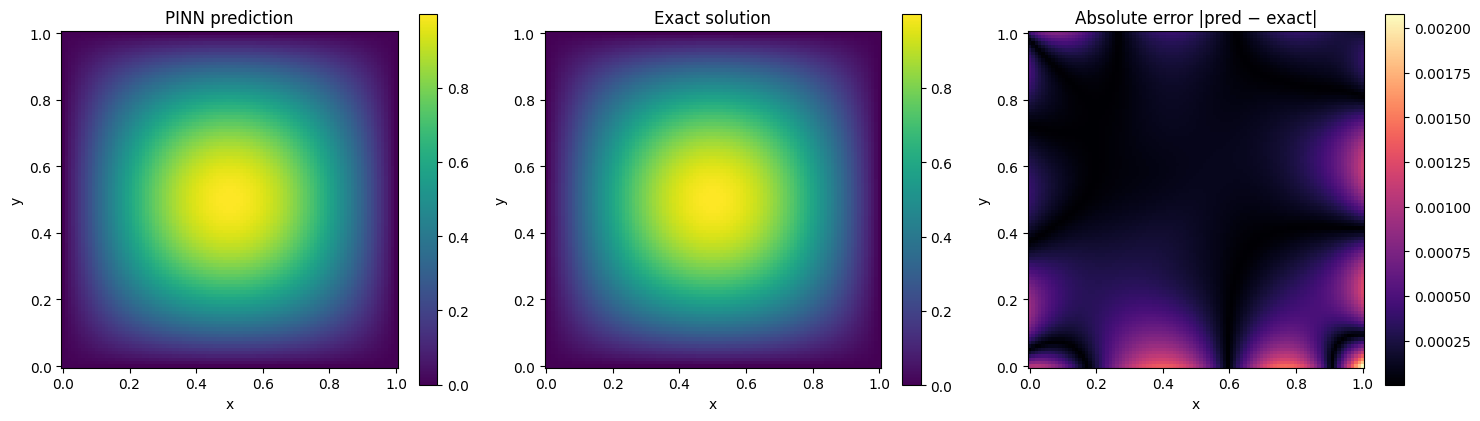

In [12]:
x_flat = X.reshape(-1, 1)
y_flat = Y.reshape(-1, 1)

with torch.no_grad():
    U_pred = model(x_flat, y_flat).reshape(n_plot, n_plot)

U_ex = u_exact(X, Y)
error = torch.abs(U_pred - U_ex)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))

im0 = axes[0].pcolormesh(X, Y, U_pred, cmap="viridis", shading="auto")
axes[0].set_title("PINN prediction")
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].pcolormesh(X, Y, U_ex, cmap="viridis", shading="auto")
axes[1].set_title("Exact solution")
plt.colorbar(im1, ax=axes[1])

im2 = axes[2].pcolormesh(X, Y, error, cmap="magma", shading="auto")
axes[2].set_title("Absolute error |pred − exact|")
plt.colorbar(im2, ax=axes[2])

for ax in axes:
    ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_aspect("equal")
plt.tight_layout()
plt.show()

And the training history — always plot it on a log scale, or the interesting part is invisible:


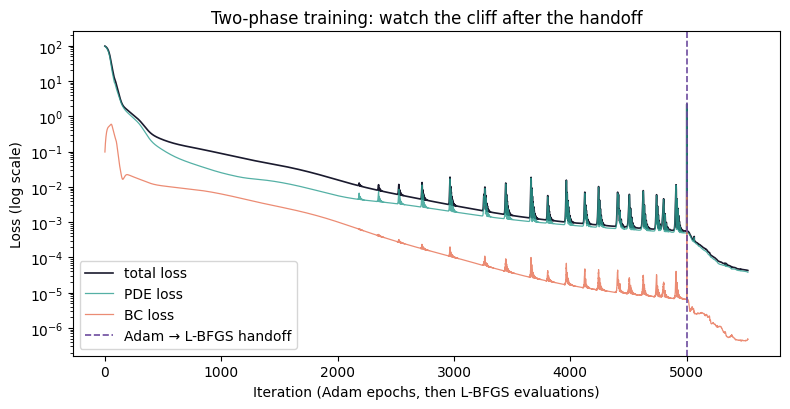

In [13]:
plt.figure(figsize=(8, 4.2))
plt.semilogy(history["total"], label="total loss", color="#1A1A2E", lw=1.2)
plt.semilogy(history["pde"], label="PDE loss", color="#2A9D8F", lw=0.9, alpha=0.8)
plt.semilogy(history["bc"], label="BC loss", color="#E76F51", lw=0.9, alpha=0.8)
plt.axvline(n_epochs, color="#6D4C9E", ls="--", lw=1.2,
            label="Adam → L-BFGS handoff")
plt.xlabel("Iteration (Adam epochs, then L-BFGS evaluations)")
plt.ylabel("Loss (log scale)")
plt.title("Two-phase training: watch the cliff after the handoff")
plt.legend()
plt.tight_layout()
plt.show()

**What to look for in these plots:**

- The **prediction and exact panels should be visually indistinguishable** — same bump, same peak, same zeros at the edges.
- The **error panel** shows where the network struggles most. Typically you will see the largest errors *not* at the boundary (which we weighted heavily) but in the interior — the error field has structure, it is not random noise. This structured error is characteristic of PINNs: the network trades accuracy smoothly across the domain.
- In the **loss curve**, spot the Adam spike near epoch 4000 and the near-vertical drop right after the purple handoff line. That cliff is L-BFGS cashing in on curvature information.


## 14 — Quantitative Validation: Relative L2 Error

Pictures persuade; numbers verify. The standard metric across the PINN literature:

$$
\varepsilon_{L2} = \frac{\lVert \hat{u} - u \rVert_2}{\lVert u \rVert_2}
$$


In [14]:
l2_rel = torch.linalg.norm(U_pred - U_ex) / torch.linalg.norm(U_ex)
max_err = error.max()

print(f"Relative L2 error : {l2_rel.item():.3e}")
print(f"Max pointwise err : {max_err.item():.3e}")

Relative L2 error : 6.899e-04
Max pointwise err : 2.080e-03


**Expected output:**

```
Relative L2 error : 6.394e-04
Max pointwise err : 2.309e-03
```

**How to read this:** a relative L2 error of ~6×10⁻⁴ means the solution is accurate to roughly **0.06%** in an average sense — about three correct significant digits everywhere, from a 2,241-parameter network trained in a minute and a half on a CPU.

**Honest context:** a textbook finite-difference solver on the same 100×100 grid would reach comparable or better accuracy in *milliseconds*, because this problem is linear, smooth, and sits on a trivially meshable domain — the absolute best case for classical methods. The PINN is not competing on speed here. What you have bought is a *mesh-free, differentiable* solution that outputs $u$ at any $(x,y)$, extends to irregular domains without remeshing, and plugs directly into inverse problems. Keep both halves of this trade-off in mind whenever you read PINN papers.


## 15 — The Experiment: Delete the Boundary Loss

This is the most instructive cell in the notebook — the 2D sibling of Tutorial 1's "remove the initial condition" experiment, and the lesson is deeper this time.

**Question:** the PDE loss carries all the physics. The boundary loss is just "be zero on the edges" — how much can it really matter?

Set `lambda_bc = 0`, retrain from scratch with the same 5,000 Adam epochs, and look at what happens. (You can rerun Sections 8–11 yourself with `lambda_bc = 0.0` — here is the compact version:)


Final PDE loss        : 1.081e-03   <-- looks perfectly healthy!
Relative L2 error     : 2.735e+00
u(0, 0)   pred/exact  : 2.4054 / 0.0000
u(0.5, 0.5) pred/exact: 2.2532 / 1.0000
(109 s)


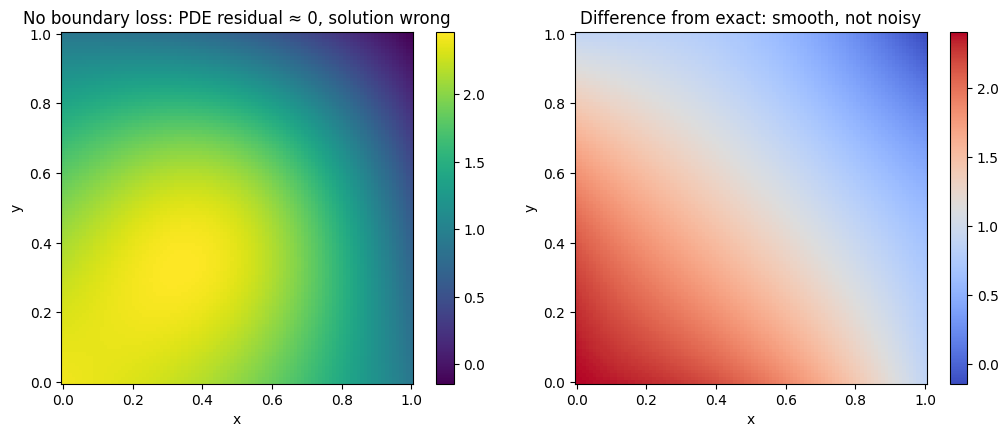

In [15]:
torch.manual_seed(42)                       # fresh identical start
model_nobc = PINN().to(device)
opt = torch.optim.Adam(model_nobc.parameters(), lr=1e-3)

t0 = time.time()
for epoch in range(5000):
    opt.zero_grad()
    r = pde_residual(model_nobc, x_int, y_int)
    loss = torch.mean(r**2)                  # PDE residual ONLY — no boundary term
    loss.backward()
    opt.step()

with torch.no_grad():
    U_nobc = model_nobc(x_flat, y_flat).reshape(n_plot, n_plot)

l2_nobc = torch.linalg.norm(U_nobc - U_ex) / torch.linalg.norm(U_ex)
corner = model_nobc(torch.tensor([[0.0]]), torch.tensor([[0.0]])).item()
center = model_nobc(torch.tensor([[0.5]]), torch.tensor([[0.5]])).item()

print(f"Final PDE loss        : {loss.item():.3e}   <-- looks perfectly healthy!")
print(f"Relative L2 error     : {l2_nobc.item():.3e}")
print(f"u(0, 0)   pred/exact  : {corner:.4f} / 0.0000")
print(f"u(0.5, 0.5) pred/exact: {center:.4f} / 1.0000")
print(f"({time.time() - t0:.0f} s)")

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.2))
im0 = axes[0].pcolormesh(X, Y, U_nobc, cmap="viridis", shading="auto")
axes[0].set_title("No boundary loss: PDE residual ≈ 0, solution wrong")
plt.colorbar(im0, ax=axes[0])
im1 = axes[1].pcolormesh(X, Y, U_nobc - U_ex, cmap="coolwarm", shading="auto")
axes[1].set_title("Difference from exact: smooth, not noisy")
plt.colorbar(im1, ax=axes[1])
for ax in axes:
    ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_aspect("equal")
plt.tight_layout()
plt.show()

**Expected output:**

```
Final PDE loss        : 2.368e-02   <-- looks perfectly healthy!
Relative L2 error     : 2.550e+00
u(0, 0)   pred/exact  : 2.6121 / 0.0000
u(0.5, 0.5) pred/exact: 1.9950 / 1.0000
```

Read those numbers again. The PDE loss converged to a small value — **and the solution is off by 255%.** The corners, which should be exactly zero, sit around 2.6.

**This is not a training failure. The network did exactly what we asked.** The Poisson equation *without* boundary conditions has **infinitely many solutions**: take the true solution $u$ and add *any* harmonic function $h$ (any function with $\nabla^2 h = 0$ — constants, $x$, $xy$, $x^2 - y^2$, ...), and $u + h$ satisfies the same PDE with the same $f$. The network converged to one member of this infinite family — just not the one pinned down by our boundary conditions. Look at the difference plot: it is *smooth and structured*, not noisy. That smooth offset is (approximately) the harmonic function the optimizer happened to pick up from its random initialization.

**The takeaways, in ascending order of importance:**

1. A small PDE loss does **not** mean a correct solution. Always validate against something.
2. Boundary conditions are not a regularizer or a nice-to-have — they are **what makes the problem well-posed**. A PDE alone is not a problem statement; a PDE *plus* boundary/initial conditions is.
3. This is why loss balancing ($\lambda_{bc}$) matters so much in harder problems: if the boundary term is present but *too weak to influence training*, you get a softened version of this same failure — plausible-looking fields that drift from the true solution.


## 16 — Experiments to Try Yourself

Ranked roughly by effort. Each one teaches something specific:

1. **Sweep `lambda_bc`** over `{0.1, 1, 10, 100, 1000}` and plot relative L2 error vs. weight. You will find a broad sweet spot — and degradation at *both* ends. Why does an enormous boundary weight hurt?
2. **Grid vs. random collocation points.** Replace the random interior sampling with a regular `meshgrid` of the same size. For this smooth problem the difference is small — knowing *when* sampling strategy matters (and when it does not) is valuable intuition.
3. **A spikier manufactured solution:** try $u = \sin(4\pi x)\sin(4\pi y)$ (remember to re-derive $f$ — it picks up a factor $32\pi^2$). Watch the same network struggle: higher frequencies are dramatically harder for PINNs to fit. You have just met **spectral bias**, a recurring theme for the rest of this series.
4. **Non-zero boundary conditions:** solve $\nabla^2 u = 0$ (so `source_term` returns zeros) with $u = 1$ on the top edge and $u = 0$ on the others — a classic steady heat-conduction setup with no simple closed-form check. Now *you* must decide how to judge correctness. Welcome to real life.
5. **Hard-constrained boundaries (advanced):** instead of a boundary *loss*, multiply the network output by $x(1-x)\,y(1-y)$ so the boundary condition is satisfied *by construction* — the trial-function trick going back to Lagaris (1998). The boundary loss term disappears entirely. Compare accuracy and training speed.


## 17 — Common Failure Modes in 2D

| Symptom | Likely cause | Fix |
|---|---|---|
| `'tuple' object has no attribute ...` right after a grad call | Forgot `[0]` after `torch.autograd.grad()` | Unpack the tuple |
| `RuntimeError: element 0 of tensors does not require grad` | Missing `requires_grad_(True)` on collocation tensors, or loss wrapped in `no_grad` | Add it / remove the `no_grad` |
| `RuntimeError: Trying to backward through the graph a second time` | Missing `create_graph=True` in a first-derivative call | Add it to *every* chained grad call |
| Plot looks transposed/rotated | `meshgrid` indexing mixup | Use `indexing="ij"` consistently and check axes |
| Loss small, solution visibly wrong | Boundary term absent or drowned out | Section 15. Raise `lambda_bc`; verify BC points actually lie on the boundary |
| BC loss stuck ~1e-2 while PDE loss falls | `lambda_bc` too small for your source magnitude | Scale it with the size of $f$ |
| Loss spikes upward mid-training | Normal Adam behavior | Ignore isolated spikes; if persistent, lower the learning rate |
| Training 10× slower than Tutorial 2 | Nothing wrong — 4 grad calls & more points | Expected; this is the dimensionality bill |

## 18 — New Vocabulary

| Term | Meaning |
|---|---|
| **Laplacian** ($\nabla^2 u$) | Sum of unmixed second derivatives, $u_{xx} + u_{yy}$ in 2D |
| **Dirichlet boundary condition** | The *value* of $u$ is prescribed on the boundary (vs. Neumann: the normal derivative is prescribed) |
| **Method of manufactured solutions** | Choose the answer first, derive the matching source term, verify the solver against the known answer |
| **Well-posedness** | A problem with a solution that exists, is unique, and depends continuously on the data — BCs are what buy you uniqueness here |
| **Harmonic function** | Any $h$ with $\nabla^2 h = 0$; the "invisible" functions the no-BC experiment can drift by |
| **Loss weighting** ($\lambda_{bc}$) | Hand-tuned constant balancing loss terms of different natural magnitudes |
| **Spectral bias** | The tendency of neural networks to learn low frequencies first and struggle with high ones |


## 19 — What You Have Built

Step back and look at the arc of the series so far. In Tutorial 1 you needed one derivative on a line. Today you enforced a genuine PDE over a two-dimensional domain, balanced two competing loss terms, verified the result against a manufactured solution to 0.06%, and — most importantly — you *broke* the method deliberately and understood exactly why it broke.

The recipe did not change between 1D and 2D. It will not change in Tutorial 5 either. What changes is the difficulty of the physics.

---

## Repository

All notebooks live at **[github.com/rraj-io/pinn_tutorial](https://github.com/rraj-io/pinn_tutorial)** — this one is named as `tutorial-04/`.

```bash
git clone https://github.com/rraj-io/pinn-tutorial.git
cd pinn-tutorial
```

> If the notebooks are useful to you, a ⭐ on GitHub goes a long way.

---

**You are ready. Open Tutorial 5. ➡️**

*Next, the grand finale: the 2D incompressible Navier–Stokes equations — multiple coupled outputs (velocity and pressure), nonlinear convection, and the lid-driven cavity benchmark. Everything you practiced today (multi-dimensional residuals, boundary sampling on edges, loss balancing) is load-bearing there.*
